# 📊 Business Performance Analysis – Superstore Dataset

This notebook analyzes business performance using Pandas and Matplotlib.

## Step 1: Import Libraries and Load Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"I:\Synent Technologies internship\Task - 5\DATA\train.csv")

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Step 2: Data Understanding

In [4]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Convert Date Column

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

## Step 3: Monthly Revenue Trends

In [7]:
# Create Year-Month column
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Group by month
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

# Convert to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.head()


YearMonth
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Name: Sales, dtype: float64

### Plot: Monthly Revenue Trend

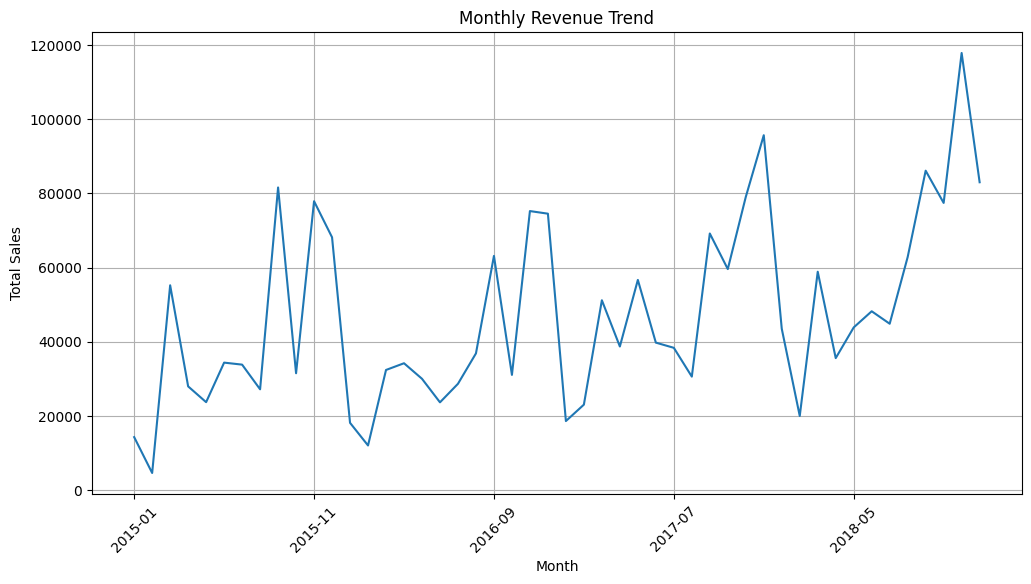

In [8]:
plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Step 4: Top-Selling Products

In [9]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

### Plot: Top 10 Products

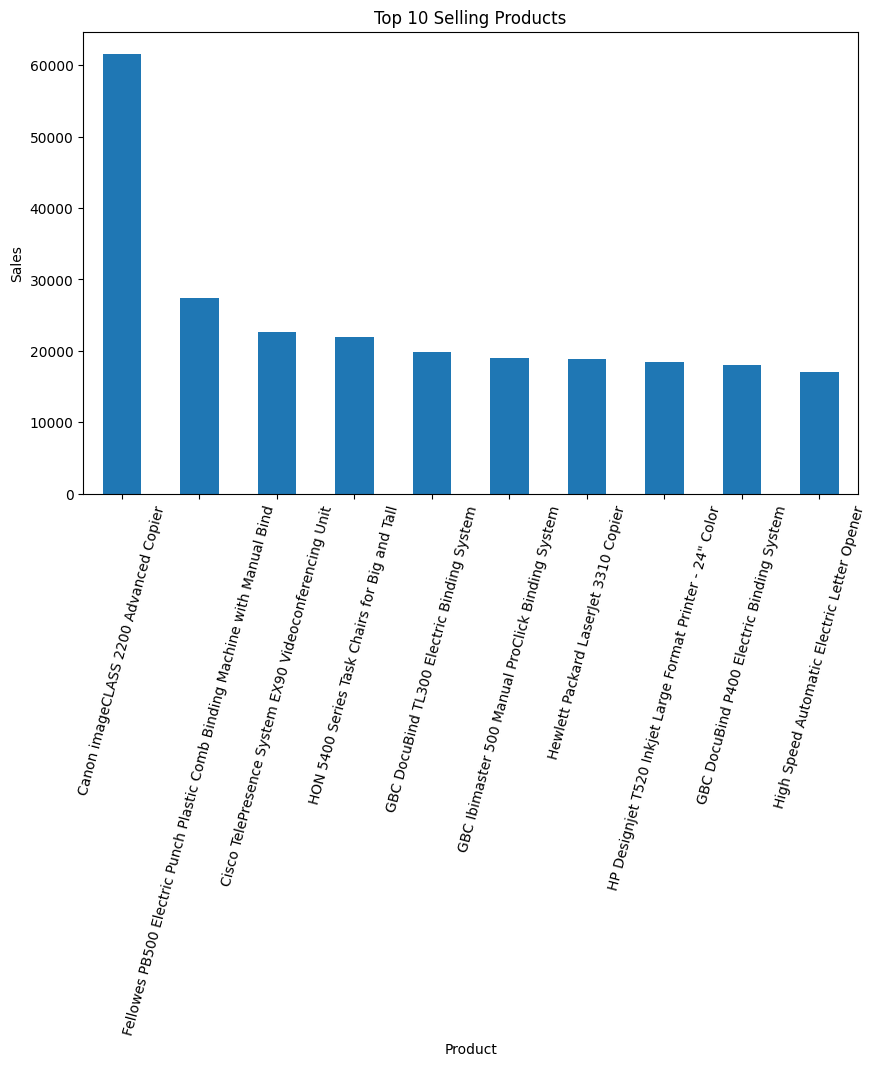

In [10]:
plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.show()

## Step 5: Profit Analysis

### Plot: Profit by Category

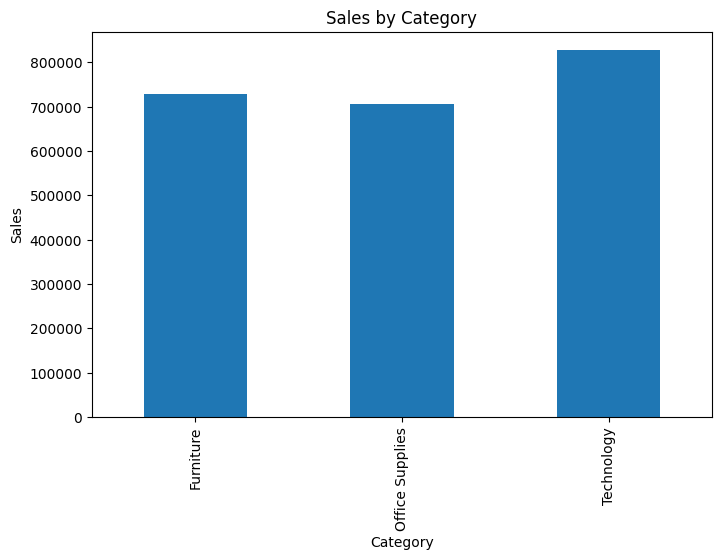

In [11]:
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

### Scatter: Sales vs Profit

Since the dataset does not include a Profit column, it was estimated as 20% of Sales.
The scatter plot shows a positive relationship between Sales and Profit.

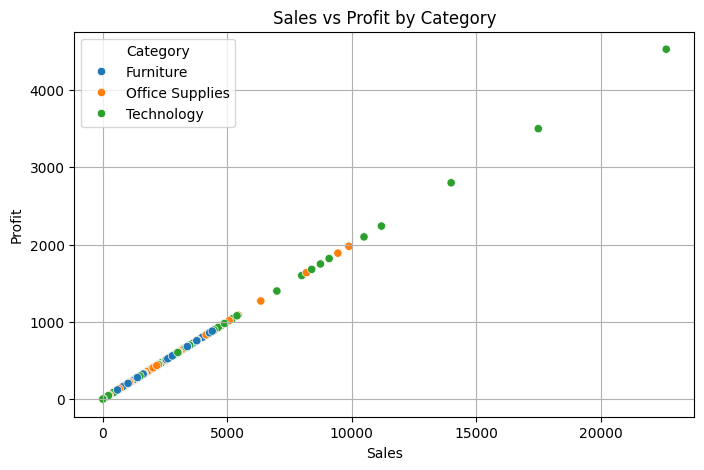

In [12]:
df['Profit'] = df['Sales'] * 0.2  # assumed 20%

plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df)

plt.title("Sales vs Profit by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid()

plt.show()

## Step 6: Region-wise Sales

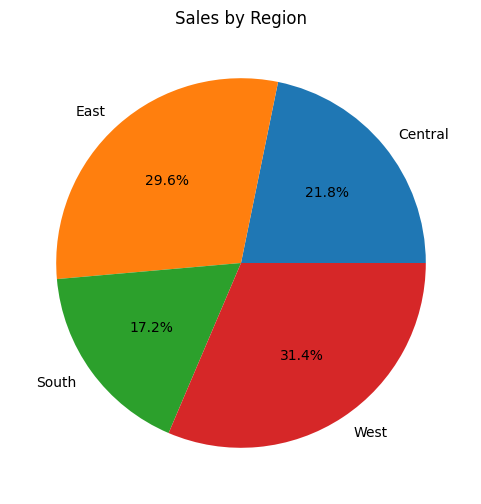

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Sales by Region")
plt.ylabel("")
plt.show()

## Step 6: Correlation Analysis
Analyze relationships between numerical variables.

In [14]:
# Select numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix

,Row ID,Postal Code,Sales,Profit
Row ID,1.000000,0.013645,0.001151,0.001151
Postal Code,0.013645,1.000000,-0.024067,-0.024067
Sales,0.001151,-0.024067,1.000000,1.000000
Profit,0.001151,-0.024067,1.000000,1.000000


### Heatmap Visualization

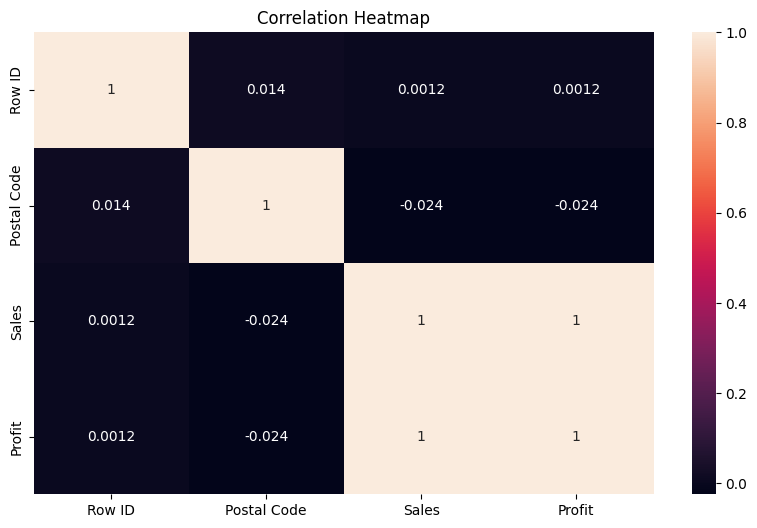

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Final Insights

1. Monthly revenue shows seasonal trends with peaks during certain months.
2. A few products contribute significantly to overall sales.
3. Some categories generate high sales but low profit.
4. Strong relationship between sales and profit, but some losses exist.
5. Region-wise analysis highlights top-performing regions.

## Conclusion

- Focus on top-performing products
- Improve profit margins
- Expand in high-performing regions
- Reduce loss-making transactions
